In [3]:
# ============================================================
# PART 1: IMPORT LIBRARIES
# ============================================================

import os
import re
import html
import string
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import tensorflow as tf

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:
# ============================================================
# PART 1.1: SET SEED AND LOAD DATASET
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

drive.mount("/content/drive")

train_path = "/content/drive/MyDrive/AI/data/train_racisit.csv"
test_path  = "/content/drive/MyDrive/AI/data/test_racisit.csv"

df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Remove unwanted index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

if "Unnamed: 0" in test_df.columns:
    test_df = test_df.drop(columns=["Unnamed: 0"])

text_column = "tweet"
label_column = "label"

df[text_column] = df[text_column].fillna("")
test_df[text_column] = test_df[text_column].fillna("")

print("Training Dataset Shape:", df.shape)
print("Testing Dataset Shape:", test_df.shape)

display(df.head())
display(test_df.head())

Mounted at /content/drive
Training Dataset Shape: (31962, 3)
Testing Dataset Shape: (17197, 2)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ============================================================
# PART 1.2: BASIC DATASET INFORMATION
# ============================================================

def show_basic_info(data, name):
    print(f"\n========== {name.upper()} ==========")
    print("Shape:", data.shape)
    print("\nFirst 5 rows:")
    display(data.head())

    print("\nDataset Info:")
    print(data.info())

    print("\nMissing Values:")
    print(data.isnull().sum())

    print("\nDuplicate Rows:")
    print(data.duplicated().sum())

    if label_column in data.columns:
        print("\nLabel Distribution:")
        print(data[label_column].value_counts())

        print("\nPercentage Distribution:")
        print(data[label_column].value_counts(normalize=True) * 100)

show_basic_info(df, "Training Dataset")


========== TRAINING DATASET ==========
Shape: (31962, 3)

First 5 rows:


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB
None

Missing Values:
id       0
label    0
tweet    0
dtype: int64

Duplicate Rows:
0

Label Distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Percentage Distribution:
label
0    92.98542
1     7.01458
Name: proportion, dtype: float64


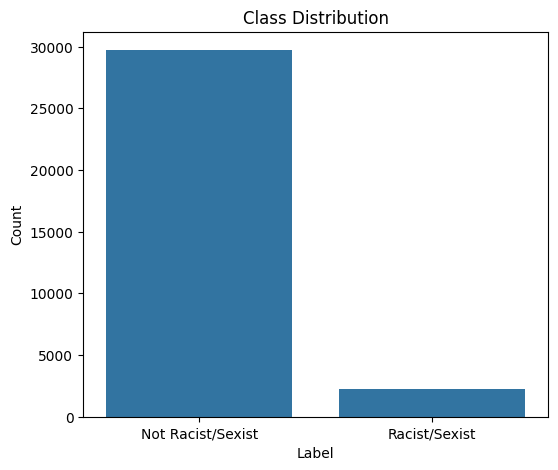

In [7]:
# ============================================================
# PART 1.3: LABEL DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(6, 5))
sns.countplot(x=label_column, data=df)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ["Not Racist/Sexist", "Racist/Sexist"])
plt.show()

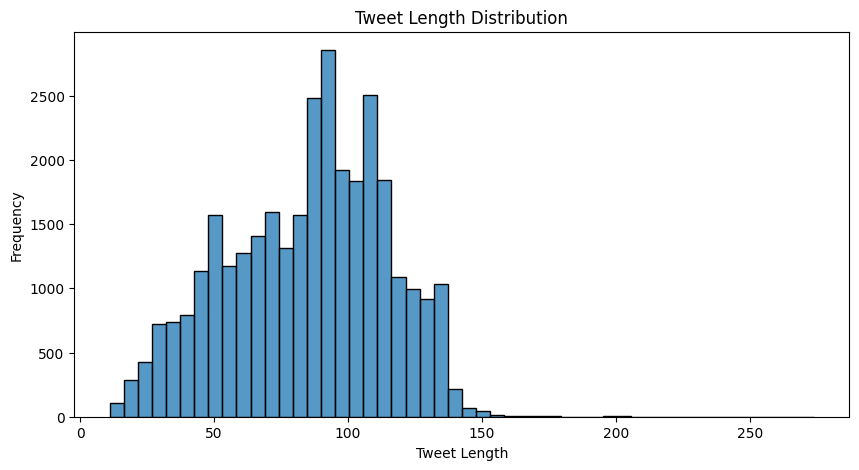

count    31962.000000
mean        84.739628
std         29.455749
min         11.000000
25%         63.000000
50%         88.000000
75%        108.000000
max        274.000000
Name: tweet_length, dtype: float64


In [8]:
# ============================================================
# PART 1.4: TWEET LENGTH ANALYSIS
# ============================================================

df["tweet_length"] = df[text_column].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df["tweet_length"], bins=50)
plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")
plt.show()

print(df["tweet_length"].describe())

In [9]:
# ============================================================
# PART 1.5: CLEAN TEXT FUNCTION
# ============================================================

lemmatizer = WordNetLemmatizer()

negation_words = {
    "no", "not", "never", "none", "nobody", "nothing", "neither",
    "nowhere", "hardly", "barely", "cannot", "can't", "don't",
    "doesn't", "didn't", "won't", "wouldn't", "shouldn't"
}

extra_stop = {
    "amp", "rt", "user", "u", "im", "ive", "dont", "cant"
}

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = (set(ENGLISH_STOP_WORDS) - negation_words).union(extra_stop)

contraction_map = {
    r"\bwon't\b": "will not",
    r"\bcan't\b": "can not",
    r"n't\b": " not",
    r"'re\b": " are",
    r"'ve\b": " have",
    r"'ll\b": " will",
    r"'d\b": " would",
    r"'m\b": " am",
}

def expand_contractions(text):
    for pattern, replacement in contraction_map.items():
        text = re.sub(pattern, replacement, text)
    return text

def clean_text(text):
    text = html.unescape(str(text).lower())
    text = expand_contractions(text)

    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)

    text = text.replace("!", " exclam_token ")
    text = text.replace("?", " question_token ")

    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"\d+", " ", text)

    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.encode("ascii", "ignore").decode("ascii")

    tokens = re.findall(r"\b\w+\b", text)

    cleaned_tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in stop_words and len(tok) > 1
    ]

    return " ".join(cleaned_tokens)

In [10]:
# ============================================================
# PART 1.6: APPLY CLEANING
# ============================================================

df["clean_tweet"] = df[text_column].apply(clean_text)
test_df["clean_tweet"] = test_df[text_column].apply(clean_text)

print("Sample Cleaned Tweets:")
for i in range(5):
    print("\nOriginal:", df[text_column].iloc[i])
    print("Cleaned :", df["clean_tweet"].iloc[i])

# Drop empty cleaned rows
empty_rows = df[df["clean_tweet"].str.strip() == ""].index
print("\nEmpty cleaned rows:", len(empty_rows))

df = df.drop(empty_rows).reset_index(drop=True)

display(df[[text_column, "clean_tweet", label_column]].head())

Sample Cleaned Tweets:

Original:  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
Cleaned : father dysfunctional selfish drag kid dysfunction run

Original: @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
Cleaned : thanks lyft credit not use cause not offer wheelchair van pdx disapointed getthanked

Original:   bihday your majesty
Cleaned : bihday majesty

Original: #model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦  
Cleaned : model love time ur exclamtoken exclamtoken exclamtoken

Original:  factsguide: society now    #motivation
Cleaned : factsguide society motivation

Empty cleaned rows: 41


,tweet,clean_tweet,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...,0
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit not use cause not offer whe...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,model love time ur exclamtoken exclamtoken exc...,0
4,factsguide: society now #motivation,factsguide society motivation,0


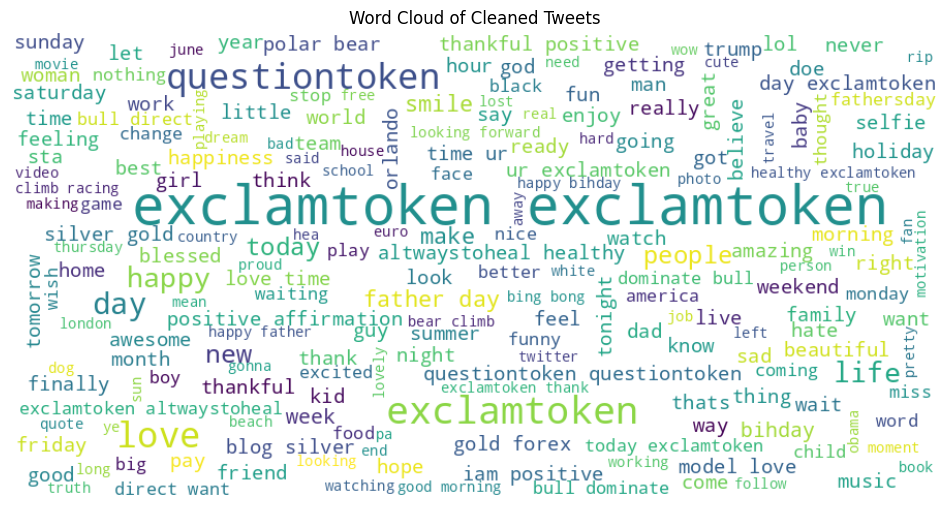

In [11]:
# ============================================================
# PART 1.7: WORD CLOUD
# ============================================================

corpus = " ".join(df["clean_tweet"])

plt.figure(figsize=(12, 8))
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=200
).generate(corpus)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Tweets")
plt.show()

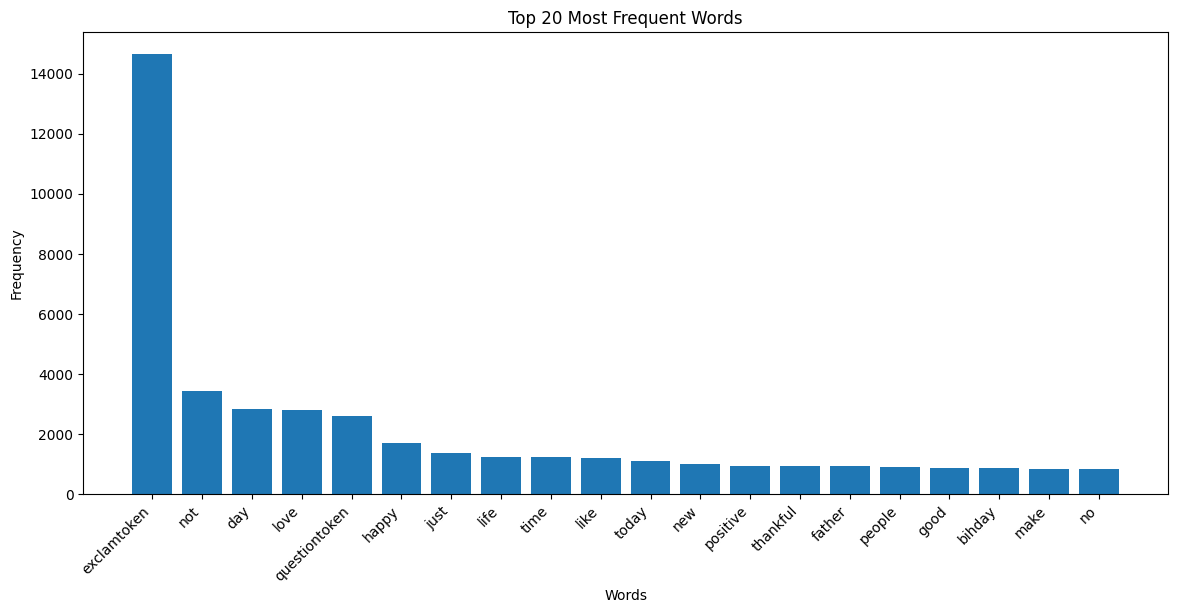

In [12]:
# ============================================================
# PART 1.8: TOP 20 WORDS
# ============================================================

word_counts = Counter(corpus.split())
top20 = dict(word_counts.most_common(20))

plt.figure(figsize=(14, 6))
plt.bar(top20.keys(), top20.values())
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [13]:
# ============================================================
# PART 2.1: TRAIN / VALIDATION SPLIT
# ============================================================

X = df["clean_tweet"]
y = df[label_column].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print("Training label distribution:")
print(y_train.value_counts())

print("\nValidation label distribution:")
print(y_val.value_counts())

Training label distribution:
label
0    23744
1     1792
Name: count, dtype: int64

Validation label distribution:
label
0    5937
1     448
Name: count, dtype: int64


In [14]:
# ============================================================
# PART 2.2: HANDLE CLASS IMBALANCE WITH CLASS WEIGHTS
# ============================================================

# Do NOT oversample validation/test data.
# We use class_weight during training to reduce overfitting from duplicated rows.

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, class_weights_values))

X_train_final = X_train.reset_index(drop=True)
y_train_final = y_train.reset_index(drop=True).astype("int32")

print("Training distribution:")
print(y_train_final.value_counts())

print("\nClass weights:")
print(class_weight)


Training distribution:
label
0    23744
1     1792
Name: count, dtype: int64

Class weights:
{np.int64(0): np.float64(0.5377358490566038), np.int64(1): np.float64(7.125)}


In [15]:
# ============================================================
# PART 2.3: TOKENIZATION AND PADDING
# ============================================================

MAX_WORDS = 12000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

# IMPORTANT: fit tokenizer only on training text to avoid data leakage
tokenizer.fit_on_texts(X_train_final)

train_sequences = tokenizer.texts_to_sequences(X_train_final)
val_sequences = tokenizer.texts_to_sequences(X_val)
test_sequences = tokenizer.texts_to_sequences(test_df["clean_tweet"])

# 95th percentile controls long noisy tweets and helps reduce overfitting
MAX_LEN = int(np.percentile([len(seq) for seq in train_sequences if len(seq) > 0], 95))
MAX_LEN = max(MAX_LEN, 5)

print("MAX_LEN:", MAX_LEN)

X_train_pad = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    val_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

y_train_final = np.array(y_train_final).astype("int32")
y_val = np.array(y_val).astype("int32")

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print("Vocab size:", vocab_size)
print("X_train_pad:", X_train_pad.shape)
print("X_val_pad:", X_val_pad.shape)


MAX_LEN: 13
Vocab size: 12000
X_train_pad: (25536, 13)
X_val_pad: (6385, 13)


In [16]:
# ============================================================
# PART 2.4: SAVE TOKENIZER AND MAX_LEN
# ============================================================

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("max_length.pkl", "wb") as f:
    pickle.dump(MAX_LEN, f)

print("Tokenizer and MAX_LEN saved successfully.")

Tokenizer and MAX_LEN saved successfully.


In [17]:
# ============================================================
# PART 2.5: COMMON MODEL SETTINGS
# ============================================================

embedding_dim = 100

# Function returns fresh callbacks for each model.
# Reusing the same EarlyStopping object across models can cause issues.
def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"{model_name}_best.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=0
        )
    ]


In [18]:
# ============================================================
# PART 2.6: MODEL 1 - SIMPLE RNN FIXED
# ============================================================

print("Building Model 1: Simple RNN")

model1 = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        mask_zero=True
    ),

    SpatialDropout1D(0.35),

    SimpleRNN(
        units=32,
        dropout=0.35,
        recurrent_dropout=0.25
    ),

    Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

model1.summary()


Building Model 1: Simple RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 64)         │       768,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 13, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,649 (2.94 MB)

 Trainable params: 771,649 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================
# PART 2.7: MODEL 2 - LSTM FIXED
# ============================================================

print("Building Model 2: LSTM")

model2 = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        mask_zero=True
    ),

    SpatialDropout1D(0.35),

    LSTM(
        units=32,
        dropout=0.35,
        recurrent_dropout=0.25
    ),

    Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

model2.summary()


Building Model 2: LSTM


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 64)         │       768,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 13, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 780,961 (2.98 MB)

 Trainable params: 780,961 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.9 MB/s eta 0:00:00


In [21]:
# gin-config is NOT needed for gensim.
# Correct install for gensim is:
!pip install -q gensim


In [22]:
# ============================================================
# PART 2.8: MODEL 3 - LSTM WITH GLOVE EMBEDDING
# ============================================================

import gensim.downloader as api

print("Loading pretrained GloVe embeddings...")
word_vectors = api.load("glove-wiki-gigaword-100")

embedding_matrix = np.zeros((vocab_size, embedding_dim))
words_found = 0

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue

    if word in word_vectors:
        embedding_matrix[i] = word_vectors[word]
        words_found += 1

coverage = (words_found / min(vocab_size - 1, len(tokenizer.word_index))) * 100

print("Words found:", words_found)
print("GloVe coverage:", round(coverage, 2), "%")

Loading pretrained GloVe embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
Words found: 9127
GloVe coverage: 76.06 %


In [23]:
# ============================================================
# PART 2.9: MODEL 3 - BUILD GLOVE LSTM FIXED
# ============================================================

print("Building Model 3: LSTM with GloVe")

model3 = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    ),

    SpatialDropout1D(0.35),

    LSTM(
        units=32,
        dropout=0.35,
        recurrent_dropout=0.25
    ),

    Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

model3.summary()


Building Model 3: LSTM with GloVe


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 100)        │     1,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 13, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217,569 (4.64 MB)

 Trainable params: 17,569 (68.63 KB)

 Non-trainable params: 1,200,000 (4.58 MB)

In [24]:
# ============================================================
# PART 2.10: MODEL OVERVIEW TABLE
# ============================================================

model_overview = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "Name": ["Simple RNN", "LSTM", "LSTM with GloVe"],
    "Embedding": ["Random Trainable", "Random Trainable", "Pretrained GloVe"],
    "Output": ["Sigmoid", "Sigmoid", "Sigmoid"],
    "Loss": ["Binary Crossentropy", "Binary Crossentropy", "Binary Crossentropy"],
    "Parameters": [
        model1.count_params(),
        model2.count_params(),
        model3.count_params()
    ]
})

model_overview

,Model,Name,Embedding,Output,Loss,Parameters
0,Model 1,Simple RNN,Random Trainable,Sigmoid,Binary Crossentropy,771649
1,Model 2,LSTM,Random Trainable,Sigmoid,Binary Crossentropy,780961
2,Model 3,LSTM with GloVe,Pretrained GloVe,Sigmoid,Binary Crossentropy,1217569


In [25]:
# ============================================================
# PART 3.1: TRAINING SETTINGS
# ============================================================

epochs = 20
batch_size = 64

histories = []
accuracies = []
precisions = []
recalls = []
f1_scores = []
thresholds = []

model_names = [
    "Simple RNN",
    "LSTM",
    "LSTM with GloVe"
]


In [26]:
# ============================================================
# PART 3.2: PLOT LEARNING CURVES FUNCTION
# ============================================================

def plot_learning_curves(history, model_name):

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)

    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)

    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")

    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

In [27]:
# ============================================================
# PART 3.3: CONFUSION MATRIX FUNCTION
# ============================================================

def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Racist/Sexist", "Racist/Sexist"],
        yticklabels=["Not Racist/Sexist", "Racist/Sexist"]
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [28]:
# ============================================================
# PART 3.4: EVALUATION FUNCTION WITH BEST VALIDATION THRESHOLD
# ============================================================

def find_best_threshold(y_true, y_prob):
    best_threshold = 0.5
    best_f1 = 0

    for threshold in np.arange(0.10, 0.91, 0.01):
        y_pred = (y_prob >= threshold).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    return best_threshold, best_f1

def evaluate_model(model, model_name):

    y_prob = model.predict(X_val_pad).ravel()

    # Choose threshold using validation F1 instead of fixed 0.10
    threshold, _ = find_best_threshold(y_val, y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    print("\n" + "="*50)
    print(model_name)
    print("="*50)
    print("Best Threshold:", round(threshold, 2))
    print("Accuracy      :", round(accuracy, 4))
    print("Precision     :", round(precision, 4))
    print("Recall        :", round(recall, 4))
    print("F1 Score      :", round(f1, 4))

    print("\nClassification Report:\n")
    print(classification_report(
        y_val,
        y_pred,
        target_names=["Not Racist/Sexist", "Racist/Sexist"],
        zero_division=0
    ))

    cm = confusion_matrix(y_val, y_pred)
    plot_confusion_matrix(cm, f"{model_name} Confusion Matrix")

    return accuracy, precision, recall, f1, threshold



Training Model 1: Simple RNN
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.4452 - loss: 0.7050 - precision: 0.0831 - recall: 0.6881 - val_accuracy: 0.8293 - val_loss: 0.6386 - val_precision: 0.2373 - val_recall: 0.6473 - learning_rate: 5.0000e-04
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7903 - loss: 0.5358 - precision: 0.2164 - recall: 0.7584 - val_accuracy: 0.9029 - val_loss: 0.3495 - val_precision: 0.4025 - val_recall: 0.7924 - learning_rate: 5.0000e-04
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8934 - loss: 0.3571 - precision: 0.3859 - recall: 0.8767 - val_accuracy: 0.9112 - val_loss: 0.2826 - val_precision: 0.4289 - val_recall: 0.8013 - learning_rate: 5.0000e-04
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9241 - loss: 0.2837 - precision: 0.4782 - recall: 0.8956 - val_accuracy: 0.9331 - val_loss: 0.2325 - val_precision: 0.5154 - val_recall: 0.7835 - learning_rate: 5.0000e-04
Epoch 5/20
399

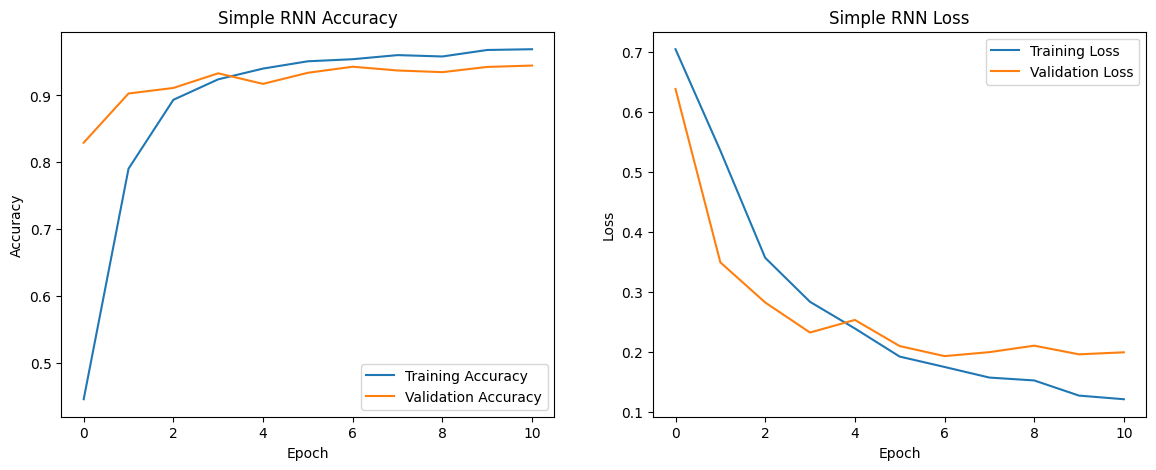

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Simple RNN
Best Threshold: 0.9
Accuracy      : 0.959
Precision     : 0.7422
Recall        : 0.6362
F1 Score      : 0.6851

Classification Report:

                   precision    recall  f1-score   support

Not Racist/Sexist       0.97      0.98      0.98      5937
    Racist/Sexist       0.74      0.64      0.69       448

         accuracy                           0.96      6385
        macro avg       0.86      0.81      0.83      6385
     weighted avg       0.96      0.96      0.96      6385



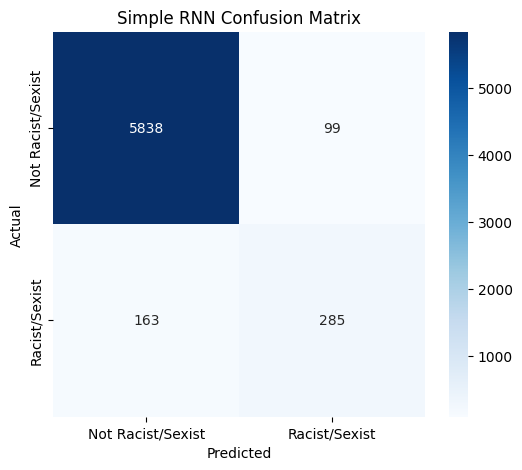

In [29]:
# ============================================================
# PART 3.5: TRAIN MODEL 1 - SIMPLE RNN
# ============================================================

print("\nTraining Model 1: Simple RNN")

history1 = model1.fit(
    X_train_pad,
    y_train_final,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=get_callbacks("model1"),
    class_weight=class_weight,
    verbose=1
)

plot_learning_curves(
    history1,
    "Simple RNN"
)

acc1, prec1, rec1, f11, th1 = evaluate_model(
    model1,
    "Simple RNN"
)

histories.append(history1)

accuracies.append(acc1)
precisions.append(prec1)
recalls.append(rec1)
f1_scores.append(f11)
thresholds.append(th1)


Training Model 2: LSTM
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7695 - loss: 0.5752 - precision: 0.1890 - recall: 0.6942 - val_accuracy: 0.8182 - val_loss: 0.4436 - val_precision: 0.2625 - val_recall: 0.8795 - learning_rate: 5.0000e-04
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8868 - loss: 0.3422 - precision: 0.3694 - recall: 0.8672 - val_accuracy: 0.8824 - val_loss: 0.3138 - val_precision: 0.3585 - val_recall: 0.8571 - learning_rate: 5.0000e-04
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9240 - loss: 0.2491 - precision: 0.4781 - recall: 0.9124 - val_accuracy: 0.9137 - val_loss: 0.2497 - val_precision: 0.4388 - val_recall: 0.8237 - learning_rate: 5.0000e-04
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9409 - loss: 0.2014 - precision: 0.5461 - recall: 0.9319 - val_accuracy: 0.9193 - val_loss: 0.2317 - val_precision: 0.4573 - val_recall: 0.8013 - learning_rate: 5.0000e-04
Epoch 5/20
399/399

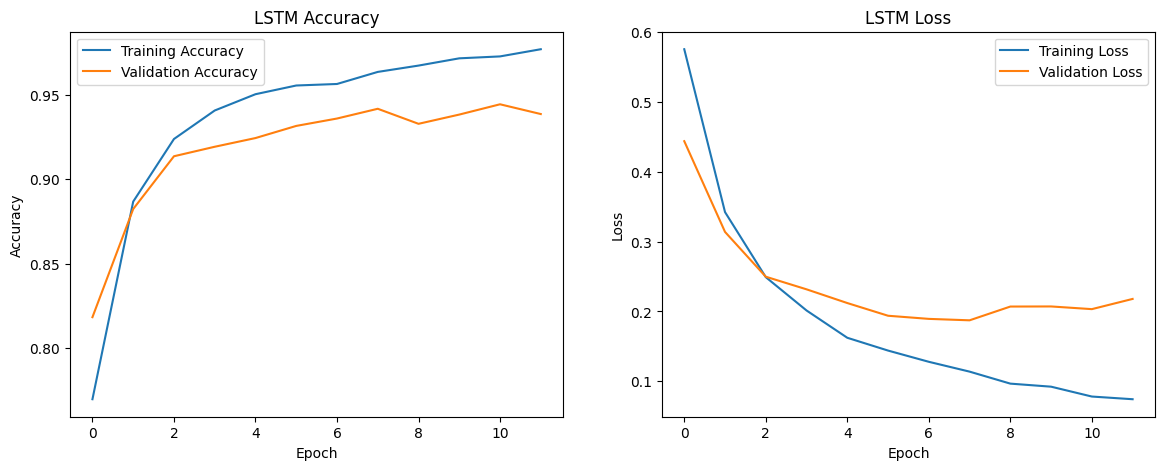

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

LSTM
Best Threshold: 0.9
Accuracy      : 0.9623
Precision     : 0.7836
Recall        : 0.6384
F1 Score      : 0.7036

Classification Report:

                   precision    recall  f1-score   support

Not Racist/Sexist       0.97      0.99      0.98      5937
    Racist/Sexist       0.78      0.64      0.70       448

         accuracy                           0.96      6385
        macro avg       0.88      0.81      0.84      6385
     weighted avg       0.96      0.96      0.96      6385



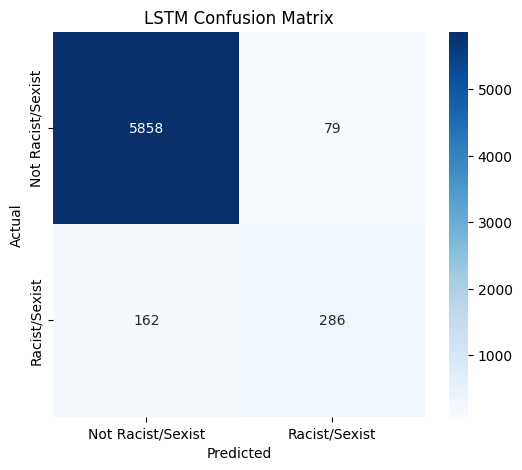

In [30]:
# ============================================================
# PART 3.6: TRAIN MODEL 2 - LSTM
# ============================================================

print("\nTraining Model 2: LSTM")

history2 = model2.fit(
    X_train_pad,
    y_train_final,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=get_callbacks("model2"),
    class_weight=class_weight,
    verbose=1
)

plot_learning_curves(
    history2,
    "LSTM"
)

acc2, prec2, rec2, f12, th2 = evaluate_model(
    model2,
    "LSTM"
)

histories.append(history2)

accuracies.append(acc2)
precisions.append(prec2)
recalls.append(rec2)
f1_scores.append(f12)
thresholds.append(th2)


Training Model 3: LSTM with GloVe
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7136 - loss: 0.6732 - precision: 0.1251 - recall: 0.5140 - val_accuracy: 0.7269 - val_loss: 0.5357 - val_precision: 0.1900 - val_recall: 0.8862 - learning_rate: 5.0000e-04
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7313 - loss: 0.5709 - precision: 0.1732 - recall: 0.7494 - val_accuracy: 0.8130 - val_loss: 0.4373 - val_precision: 0.2500 - val_recall: 0.8326 - learning_rate: 5.0000e-04
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7557 - loss: 0.5329 - precision: 0.1916 - recall: 0.7706 - val_accuracy: 0.8161 - val_loss: 0.4325 - val_precision: 0.2531 - val_recall: 0.8304 - learning_rate: 5.0000e-04
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7688 - loss: 0.5218 - precision: 0.1994 - recall: 0.7612 - val_accuracy: 0.8254 - val_loss: 0.4363 - val_precision: 0.2663 - val_recall: 0.8482 - learning_rate: 5.0000e-04
Epoch 5/20

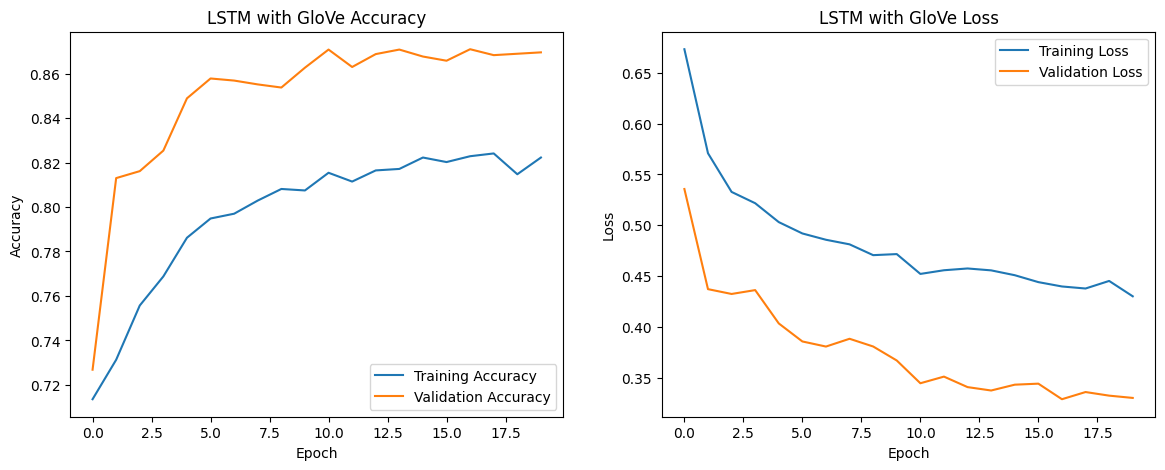

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

LSTM with GloVe
Best Threshold: 0.85
Accuracy      : 0.9417
Precision     : 0.599
Recall        : 0.5134
F1 Score      : 0.5529

Classification Report:

                   precision    recall  f1-score   support

Not Racist/Sexist       0.96      0.97      0.97      5937
    Racist/Sexist       0.60      0.51      0.55       448

         accuracy                           0.94      6385
        macro avg       0.78      0.74      0.76      6385
     weighted avg       0.94      0.94      0.94      6385



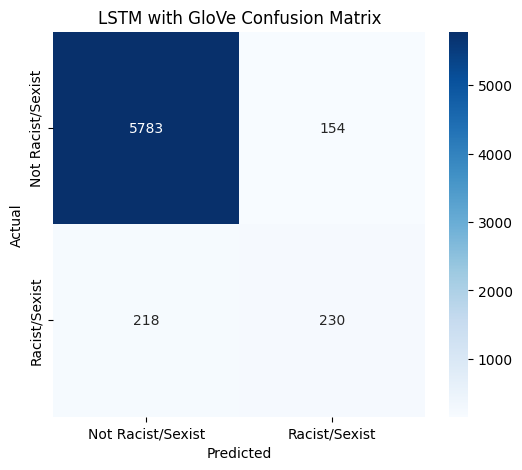

In [31]:
# ============================================================
# PART 3.7: TRAIN MODEL 3 - GLOVE LSTM
# ============================================================

print("\nTraining Model 3: LSTM with GloVe")

history3 = model3.fit(
    X_train_pad,
    y_train_final,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=get_callbacks("model3"),
    class_weight=class_weight,
    verbose=1
)

plot_learning_curves(
    history3,
    "LSTM with GloVe"
)

acc3, prec3, rec3, f13, th3 = evaluate_model(
    model3,
    "LSTM with GloVe"
)

histories.append(history3)

accuracies.append(acc3)
precisions.append(prec3)
recalls.append(rec3)
f1_scores.append(f13)
thresholds.append(th3)

In [32]:
# ============================================================
# PART 3.8: COMPARE ALL MODELS
# ============================================================

results = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies,
    "Precision": precisions,
    "Recall": recalls,
    "F1 Score": f1_scores,
    "Best Threshold": thresholds
})

results.sort_values("F1 Score", ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,Best Threshold
1,LSTM,0.962255,0.783562,0.638393,0.703567,0.90
0,Simple RNN,0.958966,0.742188,0.636161,0.685096,0.90
2,LSTM with GloVe,0.941738,0.598958,0.513393,0.552885,0.85


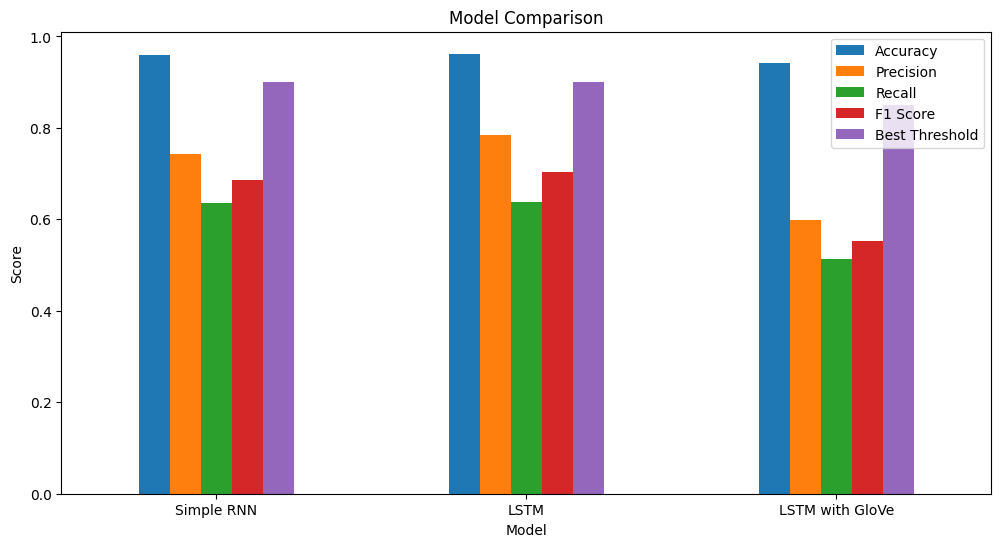

In [33]:
# ============================================================
# PART 3.9: VISUALIZE MODEL COMPARISON
# ============================================================

results.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

In [34]:
# ============================================================
# PART 3.10: SELECT BEST MODEL USING F1 SCORE
# ============================================================

best_index = np.argmax(f1_scores)

best_model = [
    model1,
    model2,
    model3
][best_index]

best_model_name = model_names[best_index]

print("Best Model:", best_model_name)

Best Model: LSTM


In [35]:
# ============================================================
# PART 3.11: SAVE BEST MODEL
# ============================================================

best_threshold = thresholds[best_index]

best_model.save("best_model.keras")

with open("best_threshold.pkl", "wb") as f:
    pickle.dump(best_threshold, f)

print("Best model saved successfully.")
print("Best threshold saved successfully:", round(best_threshold, 2))


Best model saved successfully.
Best threshold saved successfully: 0.9


In [36]:
# ============================================================
# PART 3.12: TEST DATA PREDICTION WITH BEST THRESHOLD
# ============================================================

best_threshold = thresholds[best_index]

test_prob = best_model.predict(X_test_pad).ravel()
test_pred = (test_prob >= best_threshold).astype(int)

test_df["racist_sexist_probability"] = test_prob
test_df["predicted_label"] = test_pred

test_df[[
    "tweet",
    "clean_tweet",
    "racist_sexist_probability",
    "predicted_label"
]].head()


538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,tweet,clean_tweet,racist_sexist_probability,predicted_label
0,#studiolife #aislife #requires #passion #dedic...,studiolife aislife requires passion dedication...,0.071170,0
1,@user #white #supremacists want everyone to s...,white supremacist want new bird movie here,0.931664,1
2,safe ways to heal your #acne!! #altwaystohe...,safe way heal acne exclamtoken exclamtoken alt...,0.000065,0
3,is the hp and the cursed child book up for res...,hp cursed child book reservation questiontoken...,0.011507,0
4,"3rd #bihday to my amazing, hilarious #nephew...",rd bihday amazing hilarious nephew eli ahmir e...,0.000128,0


In [37]:
# ============================================================
# PART 3.13: SAVE TEST PREDICTIONS
# ============================================================

output_path = "/content/drive/MyDrive/AI/data/final_predictions.csv"

test_df.to_csv(output_path, index=False)

print("Predictions saved to:", output_path)

Predictions saved to: /content/drive/MyDrive/AI/data/final_predictions.csv


In [38]:
# ============================================================
# PART 4.1: INSTALL AND IMPORT GRADIO
# ============================================================

!pip install gradio -q

import gradio as gr
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [39]:
# ============================================================
# PART 4.2: LOAD SAVED MODEL, TOKENIZER, MAX_LEN
# ============================================================

loaded_model = tf.keras.models.load_model("best_model.keras", compile=False)

with open("tokenizer.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)

with open("max_length.pkl", "rb") as f:
    loaded_max_len = pickle.load(f)

with open("best_threshold.pkl", "rb") as f:
    loaded_best_threshold = pickle.load(f)

print("Model, tokenizer, MAX_LEN, and threshold loaded successfully.")


Model, tokenizer, MAX_LEN, and threshold loaded successfully.


In [40]:
# ============================================================
# PART 4.3: PREDICTION FUNCTION
# ============================================================

def predict_tweet(text):
    cleaned = clean_text(text)

    sequence = loaded_tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=loaded_max_len,
        padding="post",
        truncating="post"
    )

    probability = float(loaded_model.predict(padded, verbose=0)[0][0])

    # Use validation-selected threshold from best model
    threshold = loaded_best_threshold

    if probability >= threshold:
        label = "Racist/Sexist"
    else:
        label = "Not Racist/Sexist"

    confidence = probability if label == "Racist/Sexist" else 1 - probability

    result = f"Prediction: {label}"
    confidence_text = f"Confidence: {confidence * 100:.2f}%"
    probability_text = f"Racist/Sexist Probability: {probability * 100:.2f}%"

    return result, confidence_text, probability_text


In [41]:
# ============================================================
# PART 4.4: CREATE GRADIO APP
# ============================================================

with gr.Blocks(title="Racist/Sexist Tweet Classifier") as app:

    gr.Markdown("# Racist/Sexist Tweet Classification App")
    gr.Markdown("Enter a tweet and the model will classify it as racist/sexist or not.")

    input_text = gr.Textbox(
        label="Enter Tweet",
        placeholder="Type tweet here...",
        lines=4
    )

    predict_button = gr.Button("Predict")

    result_output = gr.Textbox(label="Prediction")
    confidence_output = gr.Textbox(label="Confidence")
    probability_output = gr.Textbox(label="Racist/Sexist Probability")

    predict_button.click(
        fn=predict_tweet,
        inputs=input_text,
        outputs=[
            result_output,
            confidence_output,
            probability_output
        ]
    )

    gr.Examples(
        examples=[
            ["Have a wonderful day everyone!"],
            ["I hate all women."],
            ["This is a beautiful moment."],
            ["You people are disgusting."],
            ["I love learning machine learning."]
        ],
        inputs=input_text
    )

In [42]:
# ============================================================
# PART 4.5: LAUNCH APP
# ============================================================

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://faace358c547826323.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
